|                |   |
:----------------|---|
| **Nombre**     |Jocelyn Jiménez Buenrostro  |
| **Fecha**      |23 de marzo 2026   |
| **Expediente** |738498   |

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()


df = pd.read_csv("Heart Prediction Quantum Dataset.csv")
df.head()

Saving Heart Prediction Quantum Dataset.csv to Heart Prediction Quantum Dataset.csv


,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [3]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


EDA

- Edad -> int -> años -> [30,79]
- Género -> categórico -> {0,1}
- Presión sanguínea(sistólica) -> int -> mmHg
- ritmo cardiaco -> int -> bpm -> reposo
- Colesterol -> int -> mg/dl -> 150-300
- Enfermedad -> int

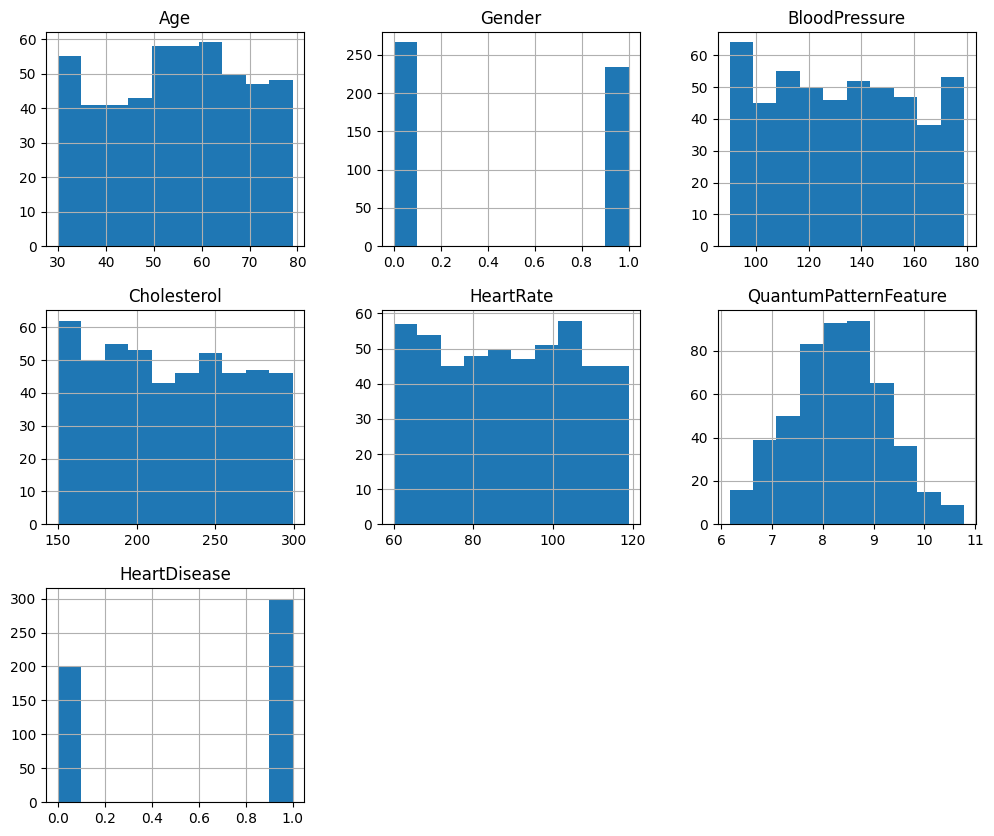

In [4]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,10))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

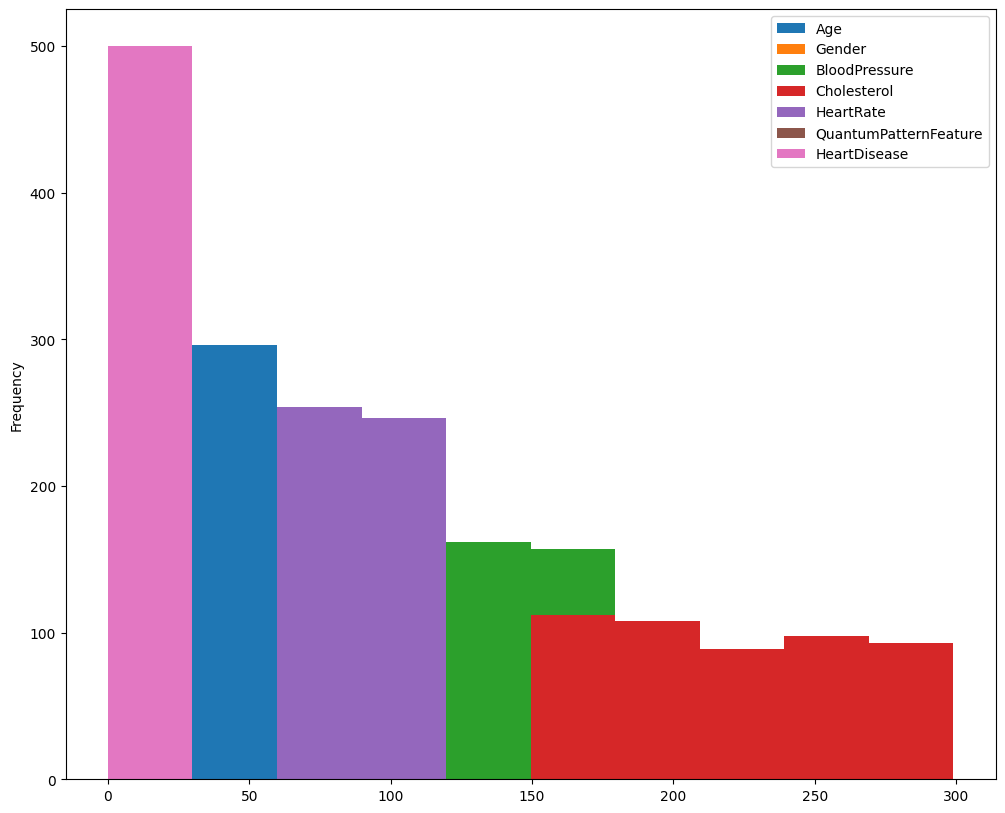

In [5]:
df.plot.hist(figsize=(12,10))
plt.show

In [6]:
numerical_columns = ['Age', 'BloodPressure', 'Cholesterol',	'HeartRate']

In [7]:
cateogorical_columns = ['Gender']

In [8]:
target_col = ['HeartDisease']

In [9]:
X = df[numerical_columns+cateogorical_columns]

In [10]:
y = df[target_col]

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

#escala datos numericos
num_transformer = StandardScaler()


In [12]:
from sklearn.neural_network import MLPClassifier

hidden_layer_sizes=(5,10)
model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, random_state=42)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


preprocessor = ColumnTransformer(transformers=[
    ('num',num_transformer,numerical_columns)
    ])

In [14]:
pipeline = Pipeline(steps=[('preprocessor',preprocessor),('model',model)])

In [15]:
pipeline.fit(X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BloodPressure',
                                                   'Cholesterol',
                                                   'HeartRate'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [16]:
pipeline.score(X,y)

0.778

In [17]:
from sklearn.model_selection import cross_val_score

cross_val_score(pipeline,X,y,scoring='roc_auc_ovo',cv=10)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't conver

array([0.84833333, 0.86666667, 0.76666667, 0.855     , 0.64666667,
       0.88666667, 0.87333333, 0.81833333, 0.855     , 0.87333333])

**¿Cuál es la mejor combinación de capa de neuronas con el código de optimización Bayesiana?**

In [18]:
from sklearn.model_selection import cross_val_score
import numpy as np

In [19]:
from sklearn.model_selection import cross_val_score

def f(hidden_layer):

    model = MLPClassifier(hidden_layer_sizes=hidden_layer, random_state=42, max_iter=1000)

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, scoring='roc_auc_ovo', cv=10)

    return np.mean(scores)

In [20]:
X_gp = np.array([[5], [10], [20]])
y_gp = np.array([[f((5,))], [f((10,))], [f((20,))]])

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor

gp = GaussianProcessRegressor(random_state=42)

In [22]:
X_sim = np.linspace(5, 20, 50).reshape(-1,1)

In [23]:
for i in range(10):

    gp.fit(X_gp, y_gp)

    y_pred, sigma = gp.predict(X_sim, return_std=True)

    i_max = np.argmax(y_pred)

    x_new = X_sim[i_max]

    y_new = f((int(x_new[0]),))

    X_gp = np.vstack((X_gp, x_new))
    y_gp = np.vstack((y_gp, y_new))

    print(f"{i}: x={x_new[0]}, AUC={y_new}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

0: x=20.0, AUC=0.8458333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

1: x=20.0, AUC=0.8458333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

...

7: x=20.0, AUC=0.8458333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

8: x=20.0, AUC=0.8458333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed w

9: x=20.0, AUC=0.8458333333333334


In [25]:
best_index = np.argmax(y_gp)
print("Mejor capa neuronas:", X_gp[best_index])
print("Mejor AUC:", y_gp[best_index])

Mejor capa neuronas: [20.]
Mejor AUC: [0.84583333]


Como se puede observar se evaluaron diferentes capas en el modelo con el objetivo de ver cual de ella nos daba un AUC más alto, es decir, un mejor desempeño. El resultado fue la capa (20,) con un AUC de .8458 el cual es bastante bueno y este mismo nos dice que la capacidad del modelo para clasificar es buena.